In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.svm import SVR

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

import mlflow

In [3]:
import os

os.environ["DAGSHUB_USER_TOKEN"] = "26550a8f46abb24a510ba37a8fd98412b78c0397"

In [4]:
import mlflow

mlflow.set_tracking_uri(
    "https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow"
)

In [5]:
from dagshub.auth import get_token

print(get_token()[:10])

Accessing as randomaban-beep

26550a8f46


In [6]:
import mlflow
import dagshub

mlflow.set_tracking_uri(
    "https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow"
)

dagshub.init(
    repo_owner="randomaban-beep",
    repo_name="Uber-Demand-Prediction",
    mlflow=True
)

Initialized MLflow to track repo "randomaban-beep/Uber-Demand-Prediction"

Repository randomaban-beep/Uber-Demand-Prediction initialized!

In [7]:
train_data_path = "../Dataset/train.csv"
test_data_path = "../Dataset/test.csv"

train_df = pd.read_csv(
    train_data_path,
    parse_dates=["tpep_pickup_datetime"]
).set_index("tpep_pickup_datetime")

test_df = pd.read_csv(
    test_data_path,
    parse_dates=["tpep_pickup_datetime"]
).set_index("tpep_pickup_datetime")

In [8]:
# missing value in training data

train_df.isna().sum()

lag_1            0
lag_2            0
lag_3            0
lag_4            0
region           0
total_pickups    0
avg_pickups      0
day_of_week      0
dtype: int64

In [9]:
# missing values in the test data

test_df.isna().sum()

lag_1            0
lag_2            0
lag_3            0
lag_4            0
region           0
total_pickups    0
avg_pickups      0
day_of_week      0
dtype: int64

In [10]:
# make X_train and y_train

X_train = train_df.drop(columns=["total_pickups"])

y_train = train_df["total_pickups"]

In [11]:
X_train.head()

,lag_1,lag_2,lag_3,lag_4,region,avg_pickups,day_of_week
tpep_pickup_datetime,,,,,,,
2016-01-01 01:00:00,160.0,149.0,120.0,58.0,0,140.0,4
2016-01-01 01:15:00,187.0,160.0,149.0,120.0,0,161.0,4
2016-01-01 01:30:00,194.0,187.0,160.0,149.0,0,175.0,4
2016-01-01 01:45:00,180.0,194.0,187.0,160.0,0,177.0,4
2016-01-01 02:00:00,197.0,180.0,194.0,187.0,0,185.0,4


In [12]:
# make X_test and y_test

X_test = test_df.drop(columns=["total_pickups"])

y_test = test_df["total_pickups"]

In [13]:
X_test.head()

,lag_1,lag_2,lag_3,lag_4,region,avg_pickups,day_of_week
tpep_pickup_datetime,,,,,,,
2016-03-01 00:00:00,36.0,44.0,31.0,29.0,0,38.0,1
2016-03-01 00:15:00,41.0,36.0,44.0,31.0,0,39.0,1
2016-03-01 00:30:00,35.0,41.0,36.0,44.0,0,37.0,1
2016-03-01 00:45:00,47.0,35.0,41.0,36.0,0,41.0,1
2016-03-01 01:00:00,34.0,47.0,35.0,41.0,0,38.0,1


In [14]:
from sklearn import set_config

set_config(transform_output="pandas")

In [15]:
# encode the data

encoder = ColumnTransformer([
    ("ohe", OneHotEncoder(drop="first",sparse_output=False), ["region","day_of_week"])
], remainder="passthrough", n_jobs=-1)

In [16]:
encoder

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``

In [17]:
# encode the train and test data

X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

In [18]:
import plotly
import optuna
import tqdm 

In [19]:
# set the experiment

mlflow.set_experiment("Model Selection")

<Experiment: artifact_location='mlflow-artifacts:/0a43e7cb159a4863b1237d6c30b0bf59', creation_time=1781804161330, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1781804161330, lifecycle_stage='active', name='Model Selection', tags={}, trace_location=None, workspace='default'>

In [20]:
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

In [21]:
def objective(trial):
    # start the child run
    with mlflow.start_run(nested=True) as child:
        
        # model name search space
        list_of_models = ["LR", "RF", "GBR", "XGBR"]
        model_name = trial.suggest_categorical("model_name", list_of_models)
    
        if model_name == "LR":
            model = LinearRegression()
    
        elif model_name == "RF":
            n_estimators_rf = trial.suggest_int("n_estimators_rf",10,100,step=10)
            max_depth_rf = trial.suggest_int("max_depth_rf",3,10)
            model = RandomForestRegressor(n_estimators=n_estimators_rf, 
                                          max_depth=max_depth_rf, 
                                          random_state=42, n_jobs=-1)
    
        elif model_name == "GBR":
            n_estimators_gb = trial.suggest_int("n_estimators_gb",10,100,step=10)
            learning_rate_gb = trial.suggest_float("learning_rate_gb",1e-4,1e-1, log=True)
            model = GradientBoostingRegressor(n_estimators=n_estimators_gb,learning_rate=learning_rate_gb,
            random_state=42)
    
        elif model_name == "XGBR":
            n_estimators_xgb = trial.suggest_int("n_estimators_xgb",10,100,step=10)
            learning_rate_xgb = trial.suggest_float("learning_rate_xgb",1e-4,1e-1, log=True)
            max_depth_xgb = trial.suggest_int("max_depth_xgb",3,10)
            model = XGBRegressor(n_estimators=n_estimators_xgb,
                                learning_rate=learning_rate_xgb,
                                max_depth=max_depth_xgb)
    
        # log the model name
        mlflow.log_param("model_name",model_name)
        
        # log the model parameters
        mlflow.log_params(model.get_params())
        
        # fit on the data
        model.fit(X_train_encoded,y_train)
    
        # get the predictions
        y_pred = model.predict(X_test_encoded)
    
        # calculate the loss
        loss = wape(y_test, y_pred)
    
        # log the metric
        mlflow.log_metric("WAPE", loss)
        return loss

In [22]:
# optimize the objective function

with mlflow.start_run(run_name="best_model", nested=True) as parent:

    # create a study object
    study = optuna.create_study(study_name="model_selection", direction="minimize")
    # optimize the objective function
    study.optimize(func=objective, n_trials=50, n_jobs=-1)
    
    # log the best parameters
    mlflow.log_params(study.best_params)
    # log the best error value
    mlflow.log_metric("Best_WAPE", study.best_value)

[I 2026-06-18 23:41:39,820] A new study created in memory with name: model_selection


🏃 View run unruly-sheep-500 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/aa94795c251846d2a1ebef52ddf1e693
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run gentle-flea-761 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/29769379377b41c78bbb3217fdf5cb24
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run honorable-grouse-357 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/0abd0f0d0c8d45cb801bbb19d6037089
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run agreeable-colt-115 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/15634270c47948cd85d287e2ccff529f
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Predi

[I 2026-06-18 23:42:00,374] Trial 7 finished with value: 0.11029480337274743 and parameters: {'model_name': 'LR'}. Best is trial 7 with value: 0.11029480337274743.


🏃 View run unleashed-hen-688 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/06406c0c3946468da73398052f85db7c
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:42:04,428] Trial 1 finished with value: 0.11275369827115787 and parameters: {'model_name': 'RF', 'n_estimators_rf': 40, 'max_depth_rf': 7}. Best is trial 7 with value: 0.11029480337274743.


🏃 View run abrasive-croc-713 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/4cc8cdccc5e64df683c085b7636fa04b
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:42:11,657] Trial 5 finished with value: 0.1128260755224902 and parameters: {'model_name': 'RF', 'n_estimators_rf': 20, 'max_depth_rf': 7}. Best is trial 7 with value: 0.11029480337274743.
[I 2026-06-18 23:42:12,995] Trial 0 finished with value: 0.7695110065039534 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 30, 'learning_rate_xgb': 0.0008470213879778531, 'max_depth_xgb': 7}. Best is trial 7 with value: 0.11029480337274743.


🏃 View run rogue-sponge-383 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/6198908ea8c04727a437840b3ca659fb
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:42:19,635] Trial 3 finished with value: 0.7340064777316551 and parameters: {'model_name': 'GBR', 'n_estimators_gb': 10, 'learning_rate_gb': 0.007434702092900816}. Best is trial 7 with value: 0.11029480337274743.
[I 2026-06-18 23:42:23,634] Trial 6 finished with value: 0.12616254541324748 and parameters: {'model_name': 'RF', 'n_estimators_rf': 10, 'max_depth_rf': 4}. Best is trial 7 with value: 0.11029480337274743.


🏃 View run nimble-conch-14 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/8c533e78e2884a1c9f7af2fd11addea5
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:42:40,492] Trial 4 finished with value: 0.6010651873538607 and parameters: {'model_name': 'GBR', 'n_estimators_gb': 70, 'learning_rate_gb': 0.004047900177674909}. Best is trial 7 with value: 0.11029480337274743.


🏃 View run inquisitive-bat-438 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/418be47b0e204dbebb315ba4cb37a500
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:42:42,294] Trial 9 finished with value: 0.11064164042316504 and parameters: {'model_name': 'RF', 'n_estimators_rf': 100, 'max_depth_rf': 9}. Best is trial 7 with value: 0.11029480337274743.
[I 2026-06-18 23:42:47,683] Trial 2 finished with value: 0.5072459889223973 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 100, 'learning_rate_xgb': 0.004600367920079745, 'max_depth_xgb': 6}. Best is trial 7 with value: 0.11029480337274743.


🏃 View run gentle-dog-216 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/b457f9807a60451080c03e4098713050
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:43:10,677] Trial 10 finished with value: 0.11274038481736581 and parameters: {'model_name': 'RF', 'n_estimators_rf': 50, 'max_depth_rf': 7}. Best is trial 7 with value: 0.11029480337274743.


🏃 View run abundant-hare-251 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/c661c6199c5f49d6a5705421b4e282bc
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run bald-grub-345 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/013fbf3ab4584f67aa75181ab530483d
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run unruly-grub-98 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/0eaac2d59db34e4fae6632b3d5ac25fe
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run dapper-asp-129 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/9af7f0a5fe794778a47399338b41d3d6
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflo

[I 2026-06-18 23:43:43,676] Trial 17 finished with value: 0.11029480337274743 and parameters: {'model_name': 'LR'}. Best is trial 7 with value: 0.11029480337274743.
[I 2026-06-18 23:43:55,692] Trial 12 finished with value: 0.11029480337274743 and parameters: {'model_name': 'LR'}. Best is trial 7 with value: 0.11029480337274743.
[I 2026-06-18 23:43:59,712] Trial 13 finished with value: 0.10771060287303635 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 50, 'learning_rate_xgb': 0.09387172149481554, 'max_depth_xgb': 9}. Best is trial 13 with value: 0.10771060287303635.


🏃 View run burly-sheep-863 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/c64f78d772d2476685b0899db5baa61e
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:44:02,605] Trial 20 finished with value: 0.11029480337274743 and parameters: {'model_name': 'LR'}. Best is trial 13 with value: 0.10771060287303635.
[I 2026-06-18 23:44:03,699] Trial 8 finished with value: 0.10814356225180448 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 90, 'learning_rate_xgb': 0.08504477131594909, 'max_depth_xgb': 7}. Best is trial 13 with value: 0.10771060287303635.


🏃 View run upbeat-ram-776 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/ac003daa444b448e8f6ccf595a9c5132
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run overjoyed-jay-924 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/1b534933e60f4b78a6d6370d1649375d
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run adventurous-foal-131 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/d2793b276bc44a79a1a8109abad7bf15
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:44:24,586] Trial 16 finished with value: 0.11029480337274743 and parameters: {'model_name': 'LR'}. Best is trial 13 with value: 0.10771060287303635.


🏃 View run secretive-hawk-231 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/e5ba5c28d43743bdb1ae4dda0f1779bc
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run victorious-doe-581 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/434ce2080af942009e4906e41d72c353
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:44:43,699] Trial 15 finished with value: 0.11029480337274743 and parameters: {'model_name': 'LR'}. Best is trial 13 with value: 0.10771060287303635.


🏃 View run capable-horse-763 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/a7c395aaf1d44712a066542458f5d427
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:44:51,706] Trial 11 finished with value: 0.11029480337274743 and parameters: {'model_name': 'LR'}. Best is trial 13 with value: 0.10771060287303635.


🏃 View run kindly-lark-194 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/72cfe047b7fb4693a1a0623e1bbd196e
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run magnificent-ram-677 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/aae03c9d2fd94172afde1114eb1a53a6
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:45:01,434] Trial 19 finished with value: 0.11029480337274743 and parameters: {'model_name': 'LR'}. Best is trial 13 with value: 0.10771060287303635.
[I 2026-06-18 23:45:03,768] Trial 21 finished with value: 0.12186087330398668 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 30, 'learning_rate_xgb': 0.08915931191104177, 'max_depth_xgb': 10}. Best is trial 13 with value: 0.10771060287303635.
[I 2026-06-18 23:45:11,735] Trial 14 finished with value: 0.7584391460138322 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 80, 'learning_rate_xgb': 0.000504116944635922, 'max_depth_xgb': 7}. Best is trial 13 with value: 0.10771060287303635.
[I 2026-06-18 23:45:19,732] Trial 18 finished with value: 0.10682398719007555 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 80, 'learning_rate_xgb': 0.074329384820235, 'max_depth_xgb': 9}. Best is trial 18 with value: 0.10682398719007555.
[I 2026-06-18 23:45:27,725] Trial 23 finished with value: 0.1061124902524

🏃 View run abrasive-midge-808 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/73cc3a6d02464e69a89b3a22795616f3
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run gregarious-auk-689 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/3fa01293fc534f1388b6cd2de16658bd
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run adaptable-swan-522 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/832b0268dc51438ca40fa4045647f304
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run luxuriant-fowl-619 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/458b4de247a1499e8d9b9fb0cac9c822
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Pr

[I 2026-06-18 23:45:56,009] Trial 29 finished with value: 0.10612988602656599 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 70, 'learning_rate_xgb': 0.09691173068010753, 'max_depth_xgb': 10}. Best is trial 23 with value: 0.10611249025246738.
[I 2026-06-18 23:46:03,747] Trial 26 finished with value: 0.10593187456700864 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 80, 'learning_rate_xgb': 0.09709488188739658, 'max_depth_xgb': 10}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run orderly-kite-958 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/eb28a8be558e46fbb30a09d10b52f39e
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:46:09,970] Trial 27 finished with value: 0.13730031050603844 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 60, 'learning_rate_xgb': 0.03829559094244009, 'max_depth_xgb': 10}. Best is trial 26 with value: 0.10593187456700864.
[I 2026-06-18 23:46:11,746] Trial 22 finished with value: 0.10613952183560779 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 80, 'learning_rate_xgb': 0.08816028521471964, 'max_depth_xgb': 10}. Best is trial 26 with value: 0.10593187456700864.
[I 2026-06-18 23:46:19,733] Trial 24 finished with value: 0.10598792817542863 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 80, 'learning_rate_xgb': 0.09180331573551025, 'max_depth_xgb': 10}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run entertaining-bass-94 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/4d7145682c524951ad1dc65413b1b0ba
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:46:55,769] Trial 25 finished with value: 0.10616029683687792 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 70, 'learning_rate_xgb': 0.09382909157241247, 'max_depth_xgb': 10}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run persistent-fowl-70 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/632d573196214036a9dbf88dc15d8cf9
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:47:00,543] Trial 30 finished with value: 0.27843782716516396 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 70, 'learning_rate_xgb': 0.016084729685567657, 'max_depth_xgb': 10}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run unique-penguin-542 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/257d8a3eda8946039d80e17a72d5e725
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run casual-kite-944 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/83f90cdb4c4e4d1a91e961da7bce3db8
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run enchanting-koi-299 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/73fee072c6374c40b0714fd6475b6bb8
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run silent-bird-248 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/669be295b16f41e59550103a60e5f35e
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Predicti

[I 2026-06-18 23:47:31,795] Trial 31 finished with value: 0.7771480002912209 and parameters: {'model_name': 'GBR', 'n_estimators_gb': 100, 'learning_rate_gb': 0.00015366841925348217}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run inquisitive-ox-804 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/85e5a357e7414a2db5c01c25a15fc357
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:47:35,805] Trial 34 finished with value: 0.2983215429885464 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 60, 'learning_rate_xgb': 0.017666907448323308, 'max_depth_xgb': 3}. Best is trial 26 with value: 0.10593187456700864.
[I 2026-06-18 23:47:39,755] Trial 28 finished with value: 0.13569517283958427 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 60, 'learning_rate_xgb': 0.0388728976991519, 'max_depth_xgb': 10}. Best is trial 26 with value: 0.10593187456700864.
[I 2026-06-18 23:47:43,776] Trial 32 finished with value: 0.3047486002069561 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 60, 'learning_rate_xgb': 0.01696067596574287, 'max_depth_xgb': 10}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run charming-goat-562 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/c71c3c6fd9434b9389272b131ddebfae
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:47:51,816] Trial 35 finished with value: 0.7792595690878812 and parameters: {'model_name': 'GBR', 'n_estimators_gb': 100, 'learning_rate_gb': 0.00012557558687618106}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run sedate-donkey-618 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/addd47c9c6d34ceea7520334cd60e2fe
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run crawling-shrimp-160 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/a7b71c681a094f7abba17e717a70b891
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:48:11,784] Trial 33 finished with value: 0.7803285751509357 and parameters: {'model_name': 'GBR', 'n_estimators_gb': 100, 'learning_rate_gb': 0.00011138793145127688}. Best is trial 26 with value: 0.10593187456700864.
[I 2026-06-18 23:48:23,786] Trial 36 finished with value: 0.7806020876622362 and parameters: {'model_name': 'GBR', 'n_estimators_gb': 100, 'learning_rate_gb': 0.00010776178139156234}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run exultant-ox-48 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/ccf9397c9cdb4f9991010d4b8d82ba63
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:48:28,588] Trial 40 finished with value: 0.1211728819263447 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 90, 'learning_rate_xgb': 0.031262318943709656, 'max_depth_xgb': 9}. Best is trial 26 with value: 0.10593187456700864.
[I 2026-06-18 23:48:31,807] Trial 41 finished with value: 0.11147928526656867 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 90, 'learning_rate_xgb': 0.03948311413758963, 'max_depth_xgb': 9}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run grandiose-wren-821 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/46980b06192f4943b7b4c44398331e24
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run honorable-bug-35 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/0beccdd4a7ab4da690cb8e5cd06cb1ba
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:48:40,597] Trial 38 finished with value: 0.11960891930917159 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 90, 'learning_rate_xgb': 0.03208095190550814, 'max_depth_xgb': 9}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run suave-calf-274 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/d81a44ada14543b68816344a0fc6054a
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run nosy-loon-130 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/b0f09b48d6454676898811bb5073e479
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:48:54,833] Trial 39 finished with value: 0.11253247813535537 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 90, 'learning_rate_xgb': 0.03789835550326753, 'max_depth_xgb': 9}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run unique-lark-346 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/65b4852f1cc5450d9b65a654de5a26f1
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:49:04,005] Trial 45 finished with value: 0.10679143898755918 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 80, 'learning_rate_xgb': 0.06275798243105157, 'max_depth_xgb': 10}. Best is trial 26 with value: 0.10593187456700864.
[I 2026-06-18 23:49:07,805] Trial 37 finished with value: 0.7782392672106512 and parameters: {'model_name': 'GBR', 'n_estimators_gb': 100, 'learning_rate_gb': 0.00013914027629785908}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run upbeat-stork-956 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/c0eb9e75b52f47daaba9e90576c3dfb4
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:49:16,615] Trial 43 finished with value: 0.12437665933845875 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 90, 'learning_rate_xgb': 0.029820335077554643, 'max_depth_xgb': 9}. Best is trial 26 with value: 0.10593187456700864.
[I 2026-06-18 23:49:19,903] Trial 42 finished with value: 0.11681777866738509 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 90, 'learning_rate_xgb': 0.03386742161415774, 'max_depth_xgb': 9}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run kindly-robin-122 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/123e85130e0c4dff9b6cd9cfab45ec8d
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:49:28,594] Trial 44 finished with value: 0.11646964394606851 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 90, 'learning_rate_xgb': 0.03407636273234383, 'max_depth_xgb': 9}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run unequaled-snipe-287 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/944af03a067241aba2183b846d1f7654
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:49:34,358] Trial 49 finished with value: 0.10731939274235122 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 70, 'learning_rate_xgb': 0.09595002455047895, 'max_depth_xgb': 8}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run incongruous-stag-256 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/14316c1423c5463ea2bb4b63f8c43e48
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0
🏃 View run shivering-hare-628 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/ba89a5558f8d481fa6ba1325d865031f
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:49:40,639] Trial 47 finished with value: 0.7819913382932788 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 70, 'learning_rate_xgb': 0.00012676878067771695, 'max_depth_xgb': 8}. Best is trial 26 with value: 0.10593187456700864.
[I 2026-06-18 23:49:47,827] Trial 46 finished with value: 0.12088088418774204 and parameters: {'model_name': 'XGBR', 'n_estimators_xgb': 70, 'learning_rate_xgb': 0.04075996037027785, 'max_depth_xgb': 8}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run kindly-turtle-106 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/d9fc7d4ffae3414bb612883ac8ae65e8
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


[I 2026-06-18 23:49:56,846] Trial 48 finished with value: 0.15266359321508766 and parameters: {'model_name': 'RF', 'n_estimators_rf': 100, 'max_depth_rf': 3}. Best is trial 26 with value: 0.10593187456700864.


🏃 View run best_model at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/fa0d882cc88e43fcb4866507e0993449
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


In [23]:
# best value

study.best_value

0.10593187456700864

In [24]:
# best parameters

study.best_params

{'model_name': 'XGBR',
 'n_estimators_xgb': 80,
 'learning_rate_xgb': 0.09709488188739658,
 'max_depth_xgb': 10}

In [25]:
# model value counts

study.trials_dataframe()['params_model_name'].value_counts()

params_model_name
XGBR    29
LR       8
GBR      7
RF       6
Name: count, dtype: int64

In [26]:
from optuna.visualization import (
    plot_optimization_history, 
    plot_parallel_coordinate, 
    plot_param_importances
)

In [27]:
import plotly
print(plotly.__version__)

6.8.0


In [28]:
import plotly
import optuna

from optuna.visualization import plot_optimization_history

fig = plot_optimization_history(study)
fig.show()

In [29]:
plot_parallel_coordinate(study, params=["model_name"])

In [30]:
from xgboost import XGBRegressor

best_model = XGBRegressor(
    n_estimators=80,
    learning_rate=0.09709488188739658,
    max_depth=10,
    random_state=42
)

best_model.fit(X_train_encoded, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [31]:
y_pred_train = best_model.predict(X_train_encoded)
y_pred_test = best_model.predict(X_test_encoded)

In [32]:
train_wape = wape(y_train, y_pred_train)
test_wape = wape(y_test, y_pred_test)

print(f"Train WAPE: {train_wape:.4f}")
print(f"Test WAPE: {test_wape:.4f}")

Train WAPE: 0.0957
Test WAPE: 0.1059


### Actual vs Predicted Plot

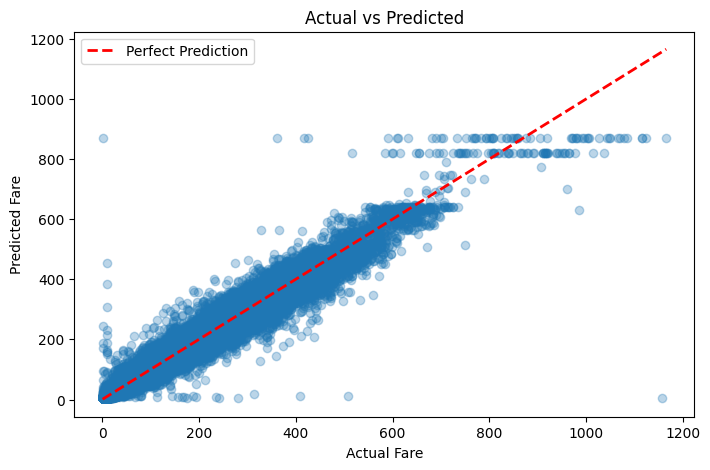

In [34]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_test, alpha=0.3)

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted")
plt.legend()

plt.show()

### Residual plot:

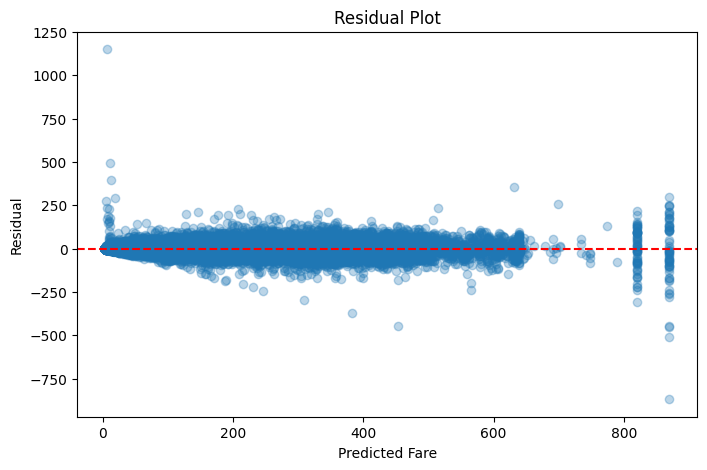

In [35]:
residuals = y_test - y_pred_test

plt.figure(figsize=(8,5))
plt.scatter(y_pred_test, residuals, alpha=0.3)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [36]:
import joblib

joblib.dump(best_model, "xgboost_model.pkl")

['xgboost_model.pkl']

In [37]:
import os
os.path.getsize("xgboost_model.pkl")

3395389

In [40]:
import mlflow.xgboost

with mlflow.start_run():

    mlflow.log_param("model", "XGBRegressor")
    mlflow.log_param("n_estimators", 80)
    mlflow.log_param("learning_rate", 0.09709488188739658)
    mlflow.log_param("max_depth", 10)

    mlflow.log_metric("train_wape", train_wape)
    mlflow.log_metric("test_wape", test_wape)

    mlflow.xgboost.log_model(best_model, "model")

2026/06/20 16:59:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run defiant-foal-224 at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0/runs/40a754e442854edc8fbb4093526af336
🧪 View experiment at: https://dagshub.com/randomaban-beep/Uber-Demand-Prediction.mlflow/#/experiments/0


In [41]:
import joblib

joblib.dump(best_model, "xgb_model.pkl")

['xgb_model.pkl']